In [ ]:
# ============================================================
# YOLO + CNN v2 HOI + BLIP + NLP + Improved Threat Reasoning
# ============================================================
from google.colab import drive, files
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from torchvision import models, transforms
from ultralytics import YOLO
from transformers import BlipProcessor, BlipForConditionalGeneration, pipeline

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.3 MB/s eta 0:00:00


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ============================================================
# 2. LOAD YOLO WEIGHTS
# ============================================================

YOLO_WEIGHTS = "/content/drive/MyDrive/yolo_weights/best.pt"

best_yolo = YOLO(YOLO_WEIGHTS)

print("YOLO loaded successfully")
print("YOLO classes:", best_yolo.names)

Using device: cuda
YOLO loaded successfully
YOLO classes: {0: 'person', 1: 'firearm'}


In [ ]:
# ============================================================
# 3. LOAD BLIP 
# ============================================================

blip_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(DEVICE)

blip_model.eval()

print("BLIP loaded correctly")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

BLIP loaded correctly


In [ ]:
# ============================================================
# 4. LOAD DISTILBERT NLP
# ============================================================

try:
    nlp_classifier = pipeline(
        "zero-shot-classification",
        model="typeform/distilbert-base-uncased-mnli",
        device=0 if torch.cuda.is_available() else -1
    )
    NLP_AVAILABLE = True
    print("DistilBERT NLP classifier loaded.")
except Exception as e:
    NLP_AVAILABLE = False
    nlp_classifier = None
    print("DistilBERT failed. Using keyword fallback.")
    print("Error:", e)

config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/258 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

DistilBERT NLP classifier loaded.


In [ ]:
# ============================================================
# 5. CNN v2 HOI ARCHITECTURE
# ============================================================

LABEL2IDX = {
    "holding": 0,
    "aiming": 1,
    "carrying": 2
}

IDX2LABEL = {
    0: "holding",
    1: "aiming",
    2: "carrying"
}

hoi_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class ThreeStreamResNet(nn.Module):
    def __init__(self, num_classes=3, pretrained=False, dropout=0.5):
        super().__init__()

        def make_stream():
            backbone = models.resnet50(weights=None)
            return nn.Sequential(*list(backbone.children())[:-1])

        self.person_stream = make_stream()
        self.object_stream = make_stream()
        self.union_stream = make_stream()

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048 * 3, 1024),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, num_classes)
        )

    def forward(self, person, obj, union):
        p = self.person_stream(person).squeeze(-1).squeeze(-1)
        o = self.object_stream(obj).squeeze(-1).squeeze(-1)
        u = self.union_stream(union).squeeze(-1).squeeze(-1)

        features = torch.cat([p, o, u], dim=1)

        return self.classifier(features)

print("ThreeStreamResNet architecture defined.")

ThreeStreamResNet architecture defined.


In [ ]:
# ============================================================
# 6. LOAD CNN v2 WEIGHTS
# ============================================================

CNN_V2_WEIGHTS = Path("/content/drive/MyDrive/yolo_weights/cnn_v2_best.pth")

if not CNN_V2_WEIGHTS.exists():
    raise FileNotFoundError(
        f"cnn_v2_best.pth not found at: {CNN_V2_WEIGHTS}\n"
        "Run this command to find it:\n"
        "!find /content/drive/MyDrive -name 'cnn_v2_best.pth'"
    )

model_v2 = ThreeStreamResNet(
    num_classes=3,
    pretrained=False,
    dropout=0.5
).to(DEVICE)

checkpoint = torch.load(
    CNN_V2_WEIGHTS,
    map_location=DEVICE
)

if isinstance(checkpoint, dict):
    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    elif "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    else:
        state_dict = checkpoint
else:
    state_dict = checkpoint

clean_state_dict = {}

for key, value in state_dict.items():
    new_key = key.replace("module.", "")
    clean_state_dict[new_key] = value

model_v2.load_state_dict(
    clean_state_dict,
    strict=True
)

model_v2.eval()

hoi_model = model_v2

print("CNN v2 HOI model loaded successfully.")
print("Final HOI model = cnn_v2_best.pth")
print("Labels:", IDX2LABEL)

CNN v2 HOI model loaded successfully.
Final HOI model = cnn_v2_best.pth
Labels: {0: 'holding', 1: 'aiming', 2: 'carrying'}


In [ ]:
# ============================================================
# 7. HELPER FUNCTIONS
# ============================================================

def crop_box_safe(image, box, padding=8):
    W, H = image.size
    x1, y1, x2, y2 = box

    x1 = max(0, int(x1) - padding)
    y1 = max(0, int(y1) - padding)
    x2 = min(W, int(x2) + padding)
    y2 = min(H, int(y2) + padding)

    if x2 <= x1:
        x2 = min(W, x1 + 1)

    if y2 <= y1:
        y2 = min(H, y1 + 1)

    return image.crop((x1, y1, x2, y2))


def box_center(box):
    x1, y1, x2, y2 = box
    return np.array([
        (x1 + x2) / 2,
        (y1 + y2) / 2
    ])


def get_class_name(names, cls_id):
    return names[int(cls_id)]


def is_person_label(label, cls_id):
    label = str(label).lower()
    return "person" in label or int(cls_id) == 0


def is_firearm_label(label, cls_id):
    label = str(label).lower()

    firearm_words = [
        "firearm",
        "gun",
        "weapon",
        "pistol",
        "rifle",
        "handgun"
    ]

    return any(word in label for word in firearm_words) or int(cls_id) == 1


def select_best_person_firearm_pair(boxes, cls_ids, confs, names, image_size):
    persons = []
    firearms = []

    for box, cls_id, conf in zip(boxes, cls_ids, confs):
        label = get_class_name(names, cls_id)

        if is_person_label(label, cls_id):
            persons.append({
                "box": box.tolist(),
                "confidence": float(conf),
                "label": label
            })

        elif is_firearm_label(label, cls_id):
            firearms.append({
                "box": box.tolist(),
                "confidence": float(conf),
                "label": label
            })

    if len(persons) == 0:
        return None, "No person detected"

    if len(firearms) == 0:
        return None, "No firearm detected"

    W, H = image_size
    diag = np.sqrt(W ** 2 + H ** 2)

    best_pair = None
    best_score = -1

    for person in persons:
        for firearm in firearms:
            person_box = person["box"]
            firearm_box = firearm["box"]

            p_center = box_center(person_box)
            f_center = box_center(firearm_box)

            distance = np.linalg.norm(p_center - f_center)
            proximity_score = 1 - min(distance / diag, 1)

            px1, py1, px2, py2 = person_box
            fx, fy = f_center

            firearm_inside_person = 1 if (
                px1 <= fx <= px2 and py1 <= fy <= py2
            ) else 0

            pair_score = (
                0.50 * firearm["confidence"] +
                0.20 * person["confidence"] +
                0.20 * proximity_score +
                0.10 * firearm_inside_person
            )

            if pair_score > best_score:
                best_score = pair_score
                best_pair = {
                    "person_box": person_box,
                    "firearm_box": firearm_box,
                    "person_confidence": person["confidence"],
                    "firearm_confidence": firearm["confidence"],
                    "person_label": person["label"],
                    "firearm_label": firearm["label"],
                    "pair_score": pair_score
                }

    return best_pair, "OK"

In [ ]:
# ============================================================
# 8. BLIP CAPTION
# ============================================================

def generate_caption(image):
    try:
        inputs = blip_processor(
            image,
            return_tensors="pt"
        ).to(DEVICE)

        with torch.no_grad():
            generated = blip_model.generate(
                **inputs,
                max_new_tokens=50
            )

        caption = blip_processor.decode(
            generated[0],
            skip_special_tokens=True
        ).strip()

        return caption

    except Exception as e:
        print("Caption generation failed:", e)
        return "Caption could not be generated."

In [ ]:
# ============================================================
# 9. NLP THREAT SCORE
# ============================================================

def keyword_threat_score(caption):
    caption = caption.lower()

    high_words = [
        "aiming",
        "pointing",
        "shooting",
        "threatening",
        "attack",
        "gun pointed"
    ]

    medium_words = [
        "gun",
        "firearm",
        "weapon",
        "pistol",
        "rifle",
        "handgun",
        "holding"
    ]

    score = 0.0

    for word in high_words:
        if word in caption:
            score += 0.25

    for word in medium_words:
        if word in caption:
            score += 0.10

    return min(score, 1.0)


def get_nlp_threat_score(caption):
    if NLP_AVAILABLE:
        candidate_labels = [
            "dangerous weapon-related situation",
            "safe normal situation"
        ]

        result = nlp_classifier(
            caption,
            candidate_labels
        )

        threat_label = "dangerous weapon-related situation"
        threat_index = result["labels"].index(threat_label)

        return float(result["scores"][threat_index]), result

    score = keyword_threat_score(caption)

    return score, {
        "labels": ["keyword-based threat score"],
        "scores": [score]
    }

In [ ]:
# ============================================================
# 10. IMPROVED THREAT REASONING
# ============================================================

def calculate_threat_score(
        action,
        action_confidence,
        firearm_confidence,
        caption):

    # Updated severity:
    # Carrying should not be LOW when firearm is detected.
    action_scores = {
        "carrying": 0.45,
        "holding": 0.65,
        "aiming": 0.95
    }

    action_score = action_scores.get(
        action.lower(),
        0.20
    )

    nlp_score, nlp_result = get_nlp_threat_score(caption)

    fused_score = (
        0.60 * action_score +
        0.20 * action_confidence +
        0.10 * firearm_confidence +
        0.10 * nlp_score
    )

    if fused_score >= 0.75:
        threat_level = "HIGH"
    elif fused_score >= 0.50:
        threat_level = "MEDIUM"
    else:
        threat_level = "LOW"

    # Safety override:
    # If YOLO detected firearm and HOI says carrying/holding,
    # minimum threat should be MEDIUM.
    if firearm_confidence >= 0.40 and action.lower() in ["carrying", "holding"]:
        if threat_level == "LOW":
            threat_level = "MEDIUM"

    # If action is aiming and firearm is detected, force HIGH.
    if firearm_confidence >= 0.40 and action.lower() == "aiming":
        threat_level = "HIGH"

    return fused_score, threat_level, nlp_score, nlp_result


def generate_reasoning(action, threat_level, caption):
    action = action.lower()

    reasons = []

    reasons.append("YOLO detected a person and firearm in the image.")

    if action == "aiming":
        reasons.append("The CNN v2 HOI model classified the interaction as aiming.")
        reasons.append("Aiming a firearm indicates immediate hostile intent and is treated as a high-risk situation.")

    elif action == "holding":
        reasons.append("The CNN v2 HOI model classified the interaction as holding.")
        reasons.append("Holding a firearm indicates active weapon possession and potential readiness.")

    elif action == "carrying":
        reasons.append("The CNN v2 HOI model classified the interaction as carrying.")
        reasons.append("Carrying a firearm is less urgent than aiming, but it still represents a security risk because a weapon is present.")

    else:
        reasons.append("The HOI model detected an unknown firearm-related interaction.")

    reasons.append(f"BLIP generated the scene caption: '{caption}'.")

    reasons.append(
        f"Based on action severity, action confidence, firearm confidence, and NLP context, the final threat level is {threat_level}."
    )

    return reasons

In [ ]:
# ============================================================
# 11. FINAL MULTIMODAL PIPELINE
# ============================================================

def multimodal_threat_pipeline(img_path, conf_thresh=0.30, show=True):
    image = Image.open(img_path).convert("RGB")

    # YOLO detection
    yolo_results = best_yolo(
        str(img_path),
        conf=conf_thresh,
        verbose=False
    )

    result = yolo_results[0]
    names = best_yolo.names
    boxes = result.boxes

    if boxes is None or len(boxes) == 0:
        return {
            "status": "failed",
            "reason": "No YOLO detections found."
        }

    cls_ids = boxes.cls.cpu().numpy().astype(int)
    xyxy = boxes.xyxy.cpu().numpy()
    confs = boxes.conf.cpu().numpy()

    pair, message = select_best_person_firearm_pair(
        xyxy,
        cls_ids,
        confs,
        names,
        image.size
    )

    if pair is None:
        return {
            "status": "failed",
            "reason": message
        }

    person_box = pair["person_box"]
    firearm_box = pair["firearm_box"]

    ux1 = min(person_box[0], firearm_box[0])
    uy1 = min(person_box[1], firearm_box[1])
    ux2 = max(person_box[2], firearm_box[2])
    uy2 = max(person_box[3], firearm_box[3])

    union_box = [ux1, uy1, ux2, uy2]

    person_crop_img = crop_box_safe(image, person_box)
    firearm_crop_img = crop_box_safe(image, firearm_box)
    union_crop_img = crop_box_safe(image, union_box)

    person_crop = hoi_transform(person_crop_img).unsqueeze(0).to(DEVICE)
    firearm_crop = hoi_transform(firearm_crop_img).unsqueeze(0).to(DEVICE)
    union_crop = hoi_transform(union_crop_img).unsqueeze(0).to(DEVICE)

    # HOI action classification
    with torch.no_grad():
        logits = hoi_model(
            person_crop,
            firearm_crop,
            union_crop
        )

        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

    action_idx = int(np.argmax(probs))
    action = IDX2LABEL[action_idx]
    action_confidence = float(probs[action_idx])

    action_probabilities = {
        IDX2LABEL[i]: float(probs[i])
        for i in range(len(probs))
    }

    # BLIP caption
    caption = generate_caption(union_crop_img)

    # Threat reasoning
    threat_score, threat_level, nlp_score, nlp_result = calculate_threat_score(
        action,
        action_confidence,
        pair["firearm_confidence"],
        caption
    )

    reasoning = generate_reasoning(
        action,
        threat_level,
        caption
    )

    final_result = {
        "status": "success",

        "person_label": pair["person_label"],
        "firearm_label": pair["firearm_label"],

        "person_confidence": pair["person_confidence"],
        "firearm_confidence": pair["firearm_confidence"],

        "action": action,
        "action_confidence": action_confidence,
        "action_probabilities": action_probabilities,

        "caption": caption,

        "nlp_threat_score": nlp_score,
        "nlp_result": nlp_result,

        "threat_score": float(threat_score),
        "threat_level": threat_level,

        "reasoning": reasoning,

        "person_box": person_box,
        "firearm_box": firearm_box,
        "union_box": union_box
    }

    if show:
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.imshow(image)

        px1, py1, px2, py2 = person_box
        fx1, fy1, fx2, fy2 = firearm_box

        ax.add_patch(
            patches.Rectangle(
                (px1, py1),
                px2 - px1,
                py2 - py1,
                linewidth=2,
                edgecolor="blue",
                facecolor="none"
            )
        )

        ax.text(
            px1,
            py1 - 8,
            f"Person {pair['person_confidence']:.2f}",
            color="blue",
            fontsize=10,
            fontweight="bold"
        )

        ax.add_patch(
            patches.Rectangle(
                (fx1, fy1),
                fx2 - fx1,
                fy2 - fy1,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )
        )

        ax.text(
            fx1,
            fy1 - 8,
            f"Firearm {pair['firearm_confidence']:.2f}",
            color="red",
            fontsize=10,
            fontweight="bold"
        )

        title = (
            f"Action: {action.upper()} ({action_confidence:.2f})\n"
            f"Threat: {threat_level} | Score: {threat_score:.2f}\n"
            f"Caption: {caption}"
        )

        ax.set_title(title, fontsize=11)
        ax.axis("off")
        plt.tight_layout()
        plt.show()

    return final_result

In [ ]:

# ============================================================
# 12. REPORT PRINTER
# ============================================================

def print_threat_report(result):
    if result["status"] != "success":
        print("Pipeline Failed:", result["reason"])
        return

    print("=" * 60)
    print("MULTIMODAL FIREARM THREAT REASONING REPORT")
    print("=" * 60)

    print("\n[YOLO Detection]")
    print(f"Person Detected  : {result['person_label']} ({result['person_confidence']:.2f})")
    print(f"Firearm Detected : {result['firearm_label']} ({result['firearm_confidence']:.2f})")

    print("\n[HOI Action Recognition]")
    print(f"Predicted Action : {result['action'].upper()}")
    print(f"Action Confidence: {result['action_confidence']:.2f}")

    print("\nAction Probabilities:")
    for label, prob in result["action_probabilities"].items():
        print(f"  {label}: {prob:.2f}")

    print("\n[BLIP Caption]")
    print(f'"{result["caption"]}"')

    print("\n[NLP Threat Analysis]")
    print(f"DistilBERT / NLP Threat Score: {result['nlp_threat_score']:.2f}")

    print("\n[Final Threat Fusion]")
    print(f"Fused Threat Score: {result['threat_score']:.2f}")
    print(f"Final Decision    : {result['threat_level']} THREAT")

    print("\n[Explainable Reasoning]")
    for i, reason in enumerate(result["reasoning"], 1):
        print(f"{i}. {reason}")

    print("=" * 60)


Model Check:
YOLO model: <class 'ultralytics.models.yolo.model.YOLO'>
HOI model: <class '__main__.ThreeStreamResNet'>
BLIP model: <class 'transformers.models.blip.modeling_blip.BlipForConditionalGeneration'>
Labels: {0: 'holding', 1: 'aiming', 2: 'carrying'}


Saving M.56.jpg to M.56.jpg


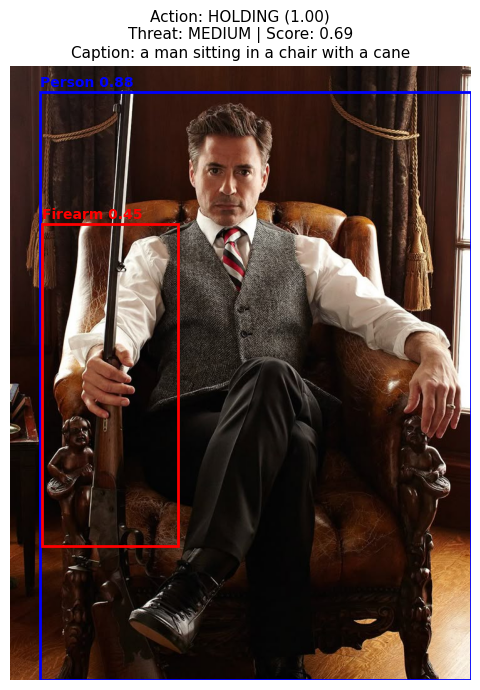

MULTIMODAL FIREARM THREAT REASONING REPORT

[YOLO Detection]
Person Detected  : person (0.88)
Firearm Detected : firearm (0.45)

[HOI Action Recognition]
Predicted Action : HOLDING
Action Confidence: 1.00

Action Probabilities:
  holding: 1.00
  aiming: 0.00
  carrying: 0.00

[BLIP Caption]
"a man sitting in a chair with a cane"

[NLP Threat Analysis]
DistilBERT / NLP Threat Score: 0.57

[Final Threat Fusion]
Fused Threat Score: 0.69
Final Decision    : MEDIUM THREAT

[Explainable Reasoning]
1. YOLO detected a person and firearm in the image.
2. The CNN v2 HOI model classified the interaction as holding.
3. Holding a firearm indicates active weapon possession and potential readiness.
4. BLIP generated the scene caption: 'a man sitting in a chair with a cane'.
5. Based on action severity, action confidence, firearm confidence, and NLP context, the final threat level is MEDIUM.


In [ ]:
# ============================================================
# 13. FINAL TEST
# ============================================================

print("\nModel Check:")
print("YOLO model:", type(best_yolo))
print("HOI model:", type(hoi_model))
print("BLIP model:", type(blip_model))
print("Labels:", IDX2LABEL)

uploaded = files.upload()
test_img = list(uploaded.keys())[0]

final_result = multimodal_threat_pipeline(
    test_img,
    conf_thresh=0.30,
    show=True
)

print_threat_report(final_result)